# Tutorial 1 Exercise Solutions

This standalone notebook solves Exercises E.1–E.3 from Tutorial 1. It follows the same workflow as the tutorial:

**blocked validation → configuration selection → full training → one final test**

The test targets are not used until the E.2 configuration and E.3 seed are fixed.


## 1. Set up and load the simulated data

The following cell imports the required tools, fixes seed 42 and checks the four data arrays.


In [1]:
from pathlib import Path
import itertools
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
KFOLDS = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
WORKING_DIRECTORY = Path.cwd()
DATASET_NAME = "synthentic_data_5_min_LV"

data_candidates = [
    WORKING_DIRECTORY / DATASET_NAME,
    WORKING_DIRECTORY / "data" / DATASET_NAME,
    WORKING_DIRECTORY.parent / "data" / DATASET_NAME,
    WORKING_DIRECTORY / "Tutorial_1_LV_Vol_Estimation" / DATASET_NAME,
]
DATA_DIRECTORY = next(
    (path for path in data_candidates if path.is_dir()),
    data_candidates[0],
)

data_files = {
    "PQ_tr": DATA_DIRECTORY / "training" / "PQ.pkl",
    "V_tr": DATA_DIRECTORY / "training" / "V.pkl",
    "PQ_te": DATA_DIRECTORY / "test" / "PQ.pkl",
    "V_te": DATA_DIRECTORY / "test" / "V.pkl",
}
missing = [path for path in data_files.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing simulated-data files:\n"
        + "\n".join(f"  - {path}" for path in missing)
    )

PQ_tr = pd.read_pickle(data_files["PQ_tr"]).to_numpy(np.float32)
V_tr = pd.read_pickle(data_files["V_tr"]).to_numpy(np.float32)
PQ_te = pd.read_pickle(data_files["PQ_te"]).to_numpy(np.float32)
V_te = pd.read_pickle(data_files["V_te"]).to_numpy(np.float32)

assert PQ_tr.shape[0] == V_tr.shape[0]
assert PQ_te.shape[0] == V_te.shape[0]
assert PQ_tr.shape[1] == PQ_te.shape[1] == 62
assert V_tr.shape[1] == V_te.shape[1] == 31
assert all(np.isfinite(array).all() for array in [PQ_tr, V_tr, PQ_te, V_te])

print(f"Data folder: {DATA_DIRECTORY.resolve()}")
print(f"Device: {DEVICE}")
print(f"Training: PQ={PQ_tr.shape}, V={V_tr.shape}")
print(f"Test: PQ={PQ_te.shape}, V={V_te.shape}")


Data folder: C:\Users\18207\Desktop\新建文件夹\Github_connection\Tutorial_1_LV_Vol_Estimation\synthentic_data_5_min_LV
Device: cpu
Training: PQ=(6048, 62), V=(6048, 31)
Test: PQ=(2016, 62), V=(2016, 31)


## 2. Shared functions

These are the same essential operations used in the main tutorial: create consecutive folds, scale within each fold, train one network and calculate validation RMSE in volts.


In [2]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def blocked_kfold_indices(n_instances, k=KFOLDS):
    fold_sizes = [n_instances // k] * k
    for i in range(n_instances % k):
        fold_sizes[i] += 1

    all_indices = np.arange(n_instances)
    folds = []
    start = 0
    for fold_size in fold_sizes:
        end = start + fold_size
        validation_indices = all_indices[start:end]
        training_indices = np.concatenate(
            [all_indices[:start], all_indices[end:]]
        )
        folds.append((training_indices, validation_indices))
        start = end
    return folds


def prepare_fold(PQ, V, training_indices, validation_indices):
    PQ_train, PQ_val = PQ[training_indices], PQ[validation_indices]
    V_train, V_val = V[training_indices], V[validation_indices]

    input_scaler = MinMaxScaler().fit(PQ_train)
    output_scaler = MinMaxScaler().fit(V_train)

    X_train = input_scaler.transform(PQ_train).astype(np.float32)
    Y_train = output_scaler.transform(V_train).astype(np.float32)
    X_val = input_scaler.transform(PQ_val).astype(np.float32)
    Y_val = output_scaler.transform(V_val).astype(np.float32)
    return X_train, Y_train, X_val, Y_val, input_scaler, output_scaler


class NNi(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_neurons, activation):
        super().__init__()
        activations = {"tanh": nn.Tanh, "relu": nn.ReLU}
        self.network = nn.Sequential(
            nn.Linear(in_dim, hidden_neurons),
            activations[activation](),
            nn.Linear(hidden_neurons, out_dim),
        )
        for layer in self.modules():
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, inputs):
        return self.network(inputs)


def train_model(model, X_train, Y_train, config):
    dataset = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(Y_train),
    )
    loader = DataLoader(
        dataset,
        batch_size=config["batch_size"],
        shuffle=True,
    )
    model = model.to(DEVICE)
    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    loss_fn = nn.MSELoss()

    for _ in range(config["epochs"]):
        model.train()
        for X_batch, Y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            Y_batch = Y_batch.to(DEVICE)
            optimiser.zero_grad()
            loss = loss_fn(model(X_batch), Y_batch)
            loss.backward()
            optimiser.step()
    return model


def predict_unscaled(model, X_scaled, output_scaler):
    model.eval()
    with torch.inference_mode():
        scaled_prediction = model(
            torch.from_numpy(X_scaled).to(DEVICE)
        ).cpu().numpy()
    return output_scaler.inverse_transform(scaled_prediction)


def evaluate_config(config, PQ, V, k=KFOLDS, seed=SEED):
    fold_rmse = []
    for training_indices, validation_indices in blocked_kfold_indices(len(PQ), k):
        X_train, Y_train, X_val, _, _, output_scaler = prepare_fold(
            PQ, V, training_indices, validation_indices
        )
        set_seed(seed)
        model = NNi(
            in_dim=X_train.shape[1],
            out_dim=Y_train.shape[1],
            hidden_neurons=config["hidden_neurons"],
            activation=config["activation"],
        )
        model = train_model(model, X_train, Y_train, config)

        V_val_estimated = predict_unscaled(model, X_val, output_scaler)
        V_val = V[validation_indices]
        fold_rmse.append(
            float(np.sqrt(np.mean((V_val - V_val_estimated) ** 2)))
        )

    return {
        **config,
        "fold_1_RMSE": fold_rmse[0],
        "fold_2_RMSE": fold_rmse[1],
        "fold_3_RMSE": fold_rmse[2],
        "RMSE_kfold": float(np.mean(fold_rmse)),
        "RMSE_std": float(np.std(fold_rmse)),
    }


## 3. E.1 — Blocked validation and scaling

The table reports each consecutive validation range and counts validation values outside `[0, 1]` after fitting scalers on training rows only.


In [3]:
fold_rows = []
range_rows = []

for fold_number, (training_indices, validation_indices) in enumerate(
    blocked_kfold_indices(len(PQ_tr)), start=1
):
    fold_rows.append(
        {
            "fold": fold_number,
            "training rows": len(training_indices),
            "validation rows": len(validation_indices),
            "validation range (1-based)": (
                f"{validation_indices[0] + 1}–{validation_indices[-1] + 1}"
            ),
        }
    )

    X_train, Y_train, X_val, Y_val, _, _ = prepare_fold(
        PQ_tr, V_tr, training_indices, validation_indices
    )
    for name, values in [("P/Q inputs", X_val), ("Voltage targets", Y_val)]:
        range_rows.append(
            {
                "fold": fold_number,
                "values": name,
                "minimum": values.min(),
                "maximum": values.max(),
                "below 0": int((values < 0).sum()),
                "above 1": int((values > 1).sum()),
            }
        )

display(pd.DataFrame(fold_rows))
display(pd.DataFrame(range_rows).round(6))


,fold,training rows,validation rows,validation range (1-based)
0,1,4032,2016,1–2016
1,2,4032,2016,2017–4032
2,3,4032,2016,4033–6048


,fold,values,minimum,maximum,below 0,above 1
0,1,P/Q inputs,-0.366800,2.227198,102,84
1,1,Voltage targets,-0.577530,1.084961,216,106
2,2,P/Q inputs,-0.327235,2.590898,46,65
3,2,Voltage targets,-0.748421,1.114944,181,72
4,3,P/Q inputs,-0.794376,2.070528,65,141
5,3,Voltage targets,-0.149384,1.100224,16,49


Values outside `[0, 1]` are valid when the validation period extends beyond the training period's minimum or maximum. Refitting on validation data would leak its range into model preparation and make validation less independent.


## 4. E.2 — Compare `tanh` and `relu`

The four configurations differ only in activation and hidden-neuron count. All are ranked by the same three blocked folds.


In [4]:
exercise_configs = [
    {
        "hidden_neurons": hidden_neurons,
        "activation": activation,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "batch_size": 72,
        "epochs": 300,
    }
    for hidden_neurons, activation in itertools.product(
        [93, 155], ["tanh", "relu"]
    )
]

exercise_rows = []
for number, config in enumerate(exercise_configs, start=1):
    result = evaluate_config(config, PQ_tr, V_tr)
    exercise_rows.append(result)
    print(
        f"Configuration {number}/4: "
        f"hidden={config['hidden_neurons']}, "
        f"activation={config['activation']}, "
        f"RMSE={result['RMSE_kfold']:.6f} V"
    )

exercise_results = (
    pd.DataFrame(exercise_rows)
    .sort_values("RMSE_kfold")
    .reset_index(drop=True)
)
display(exercise_results.round(6))

best_exercise_config = exercise_results.iloc[0].to_dict()
print("Selected E.2 configuration:")
print(f"  hidden neurons: {int(best_exercise_config['hidden_neurons'])}")
print(f"  activation: {best_exercise_config['activation']}")
print(f"  mean RMSE: {best_exercise_config['RMSE_kfold']:.6f} V")


Configuration 1/4: hidden=93, activation=tanh, RMSE=0.013641 V


Configuration 2/4: hidden=93, activation=relu, RMSE=0.025006 V


Configuration 3/4: hidden=155, activation=tanh, RMSE=0.012512 V


Configuration 4/4: hidden=155, activation=relu, RMSE=0.018176 V


,hidden_neurons,activation,lr,weight_decay,batch_size,epochs,fold_1_RMSE,fold_2_RMSE,fold_3_RMSE,RMSE_kfold,RMSE_std
0,155,tanh,0.001,0.00001,72,300,0.012947,0.012938,0.011649,0.012512,0.000610
1,93,tanh,0.001,0.00001,72,300,0.015593,0.012698,0.012630,0.013641,0.001381
2,155,relu,0.001,0.00001,72,300,0.021760,0.015374,0.017394,0.018176,0.002665
3,93,relu,0.001,0.00001,72,300,0.034374,0.028133,0.012512,0.025006,0.009195


Selected E.2 configuration:
  hidden neurons: 155
  activation: tanh
  mean RMSE: 0.012512 V


The first row is selected because it has the lowest mean validation RMSE. The test period has not been used in this comparison.


## 5. E.3 — Seed comparison, full training and final test

Keep the E.2 configuration fixed and compare seeds 0, 1 and 2 by mean blocked-validation RMSE. Then retrain the selected seed on the complete training period and inspect the held-out test result.


Seed ranking by mean blocked-validation RMSE:


,seed,RMSE_kfold,RMSE_std
0,0,0.012750,0.001270
1,2,0.013390,0.000280
2,1,0.014901,0.002484


Selected seed: 0


,metric,value
0,Overall test RMSE (V),0.015169
1,Overall test MAE (V),0.009661
2,Highest-RMSE customer,26.000000
3,Highest customer RMSE (V),0.036363


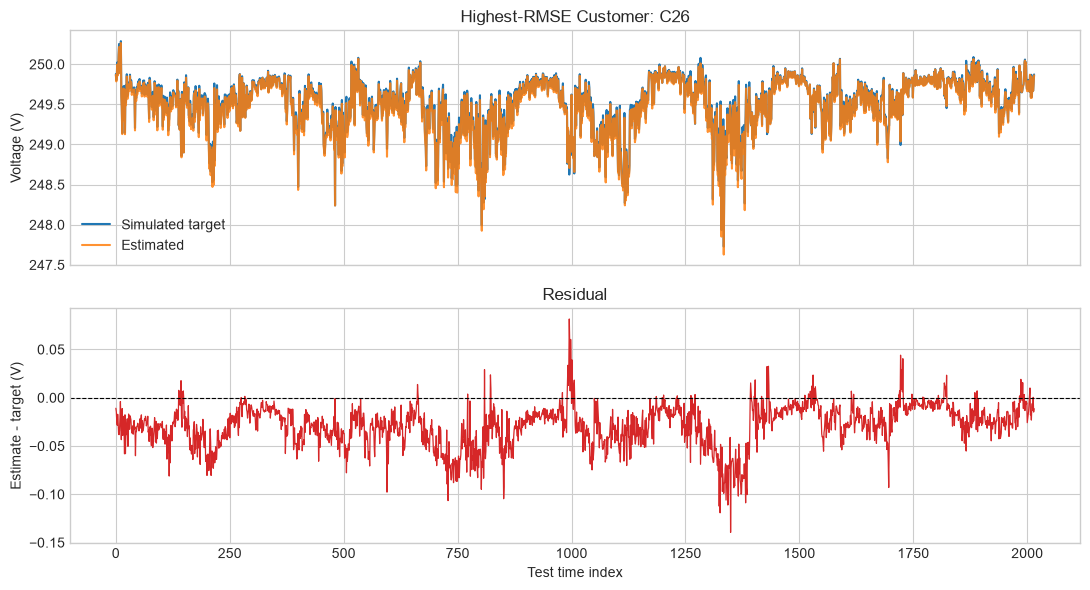

In [5]:
final_config = {
    "hidden_neurons": int(best_exercise_config["hidden_neurons"]),
    "activation": str(best_exercise_config["activation"]),
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": 72,
    "epochs": 300,
}

seed_rows = []
for seed in [0, 1, 2]:
    seed_result = evaluate_config(
        final_config,
        PQ_tr,
        V_tr,
        seed=seed,
    )
    seed_rows.append(
        {
            "seed": seed,
            "RMSE_kfold": seed_result["RMSE_kfold"],
            "RMSE_std": seed_result["RMSE_std"],
        }
    )

seed_results = (
    pd.DataFrame(seed_rows)
    .sort_values("RMSE_kfold")
    .reset_index(drop=True)
)
selected_seed = int(seed_results.iloc[0]["seed"])
print("Seed ranking by mean blocked-validation RMSE:")
display(seed_results.round(6))
print(f"Selected seed: {selected_seed}")

input_scaler_full = MinMaxScaler().fit(PQ_tr)
output_scaler_full = MinMaxScaler().fit(V_tr)
X_train_full = input_scaler_full.transform(PQ_tr).astype(np.float32)
Y_train_full = output_scaler_full.transform(V_tr).astype(np.float32)
X_test_full = input_scaler_full.transform(PQ_te).astype(np.float32)

set_seed(selected_seed)
exercise_model = NNi(
    in_dim=X_train_full.shape[1],
    out_dim=Y_train_full.shape[1],
    hidden_neurons=final_config["hidden_neurons"],
    activation=final_config["activation"],
)
exercise_model = train_model(
    exercise_model,
    X_train_full,
    Y_train_full,
    final_config,
)

V_test_estimated = predict_unscaled(
    exercise_model, X_test_full, output_scaler_full
)
test_error = V_test_estimated - V_te
test_rmse = float(np.sqrt(np.mean(test_error ** 2)))
test_mae = float(np.mean(np.abs(test_error)))
per_customer_rmse = np.sqrt(np.mean(test_error ** 2, axis=0))
worst_customer = int(np.argmax(per_customer_rmse))

metrics = pd.DataFrame(
    {
        "metric": [
            "Overall test RMSE (V)",
            "Overall test MAE (V)",
            "Highest-RMSE customer",
            "Highest customer RMSE (V)",
        ],
        "value": [
            test_rmse,
            test_mae,
            worst_customer + 1,
            per_customer_rmse[worst_customer],
        ],
    }
)
display(metrics.round(6))

time_index = np.arange(len(V_te))
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(time_index, V_te[:, worst_customer], label="Simulated target")
axes[0].plot(
    time_index,
    V_test_estimated[:, worst_customer],
    label="Estimated",
    alpha=0.85,
)
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"Highest-RMSE Customer: C{worst_customer + 1}")
axes[0].legend()

axes[1].plot(
    time_index,
    test_error[:, worst_customer],
    color="tab:red",
    linewidth=0.9,
)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Test time index")
axes[1].set_ylabel("Estimate - target (V)")
axes[1].set_title("Residual")
plt.tight_layout()
plt.show()


The metric table gives the final numerical answer. The last plot shows whether the largest customer-level errors are sustained across the complete period or concentrated in shorter intervals.
